# Simulation sensitivity analysis

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from plotting_config import TEXT_WIDTH
from minou_colours import MINOU_COLOURS as MINOU_COLORS
import pandas as pd
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D

STUDY_ROOT = Path('../..').resolve()
sys.path.insert(0, str(STUDY_ROOT))
from common.io_utils import StudyPaths, read_metrics_table
paths = StudyPaths(study_root=STUDY_ROOT)
FIGURES_DIR = paths.figures_dir / '02_sensitivity_analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 43, 44, 45, 46]
MODEL_ORDER = [('pto','linear'),('pto','mlp'),('pto','persistence'),('pto','persistence_ma4'),('dfl','linear'),('dfl','mlp'),('blackbox','linear'),('blackbox','mlp')]
MODEL_LABELS = {('pto','linear'):'PTO Linear',('pto','mlp'):'PTO MLP',('pto','persistence'):'Persistence',('pto','persistence_ma4'):'Persistence MA4',('dfl','linear'):'DFL Linear',('dfl','mlp'):'DFL MLP',('blackbox','linear'):'Black-box Linear',('blackbox','mlp'):'Black-box MLP'}
MODEL_COLORS = {
    'PTO Linear': MINOU_COLORS['gold'], 'PTO MLP': MINOU_COLORS['teal'],
    'Persistence': MINOU_COLORS['grey'], 'Persistence MA4': MINOU_COLORS['grey'],
    'DFL Linear': MINOU_COLORS['purple'], 'DFL MLP': MINOU_COLORS['sage'],
    'Black-box Linear': MINOU_COLORS['coral'], 'Black-box MLP': MINOU_COLORS['navy'],
}
PLOT_EXCLUDED_MODELS = {'Persistence', 'Persistence MA4'}
metrics = read_metrics_table(paths.master_metrics_csv)
if metrics.empty: raise FileNotFoundError(paths.master_metrics_csv)
print(f'Loaded {len(metrics)} metric rows')
print('Available T:', sorted(metrics['T'].unique()))
print('Available lambda:', sorted(metrics.lambda_shortfall.unique()))
print('Available rho:', sorted(metrics.rho_scale.unique()))

T_FIXED = 500
RHO_FIXED = 0.03
LAMBDA_FIXED = 10

Loaded 440 metric rows
Available T: [np.int64(150), np.int64(300), np.int64(500), np.int64(1000)]
Available lambda: [np.float64(0.2), np.float64(1.0), np.float64(10.0), np.float64(50.0)]
Available rho: [np.float64(0.03), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0)]


## Helper Functions

In [2]:
def complete_slice(df, varying, fixed):
    sub = df.copy()
    for col, value in fixed.items(): sub = sub[sub[col] == value]
    expected = {(s, fam, arch) for s in SEEDS for fam, arch in MODEL_ORDER}
    complete = []
    for value, g in sub.groupby(varying):
        observed = {(int(r.seed), r.model_family, r.architecture) for _, r in g.iterrows()}
        if expected.issubset(observed): complete.append(value)
        else: print(f'Skipping {varying}={value}: only {len(observed)}/{len(expected)} seed/model combinations')
    return sub[sub[varying].isin(complete)].copy()

def sensitivity_summary(df, varying):
    out = (df.groupby([varying, 'model_family', 'architecture'])['mean_regret']
             .agg(mean_regret='mean', sd_regret='std', n_seeds='count').reset_index())
    out['model'] = [MODEL_LABELS[(f, a)] for f, a in zip(out.model_family, out.architecture)]
    return out.sort_values([varying, 'model'])

def show_table(summary, varying):
    table = summary.copy()
    table['mean_regret_sd'] = table.apply(lambda r: f"{r.mean_regret:.4f} ({r.sd_regret:.4f})", axis=1)
    display(table.pivot(index=varying, columns='model', values='mean_regret_sd').reindex(columns=list(MODEL_LABELS.values())))

def plot_sensitivity(summary, varying, title, filename, xlim=None, tight_y=False):
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH, 3.0), constrained_layout=True)
    for model, g in summary.groupby('model', sort=False):
        if model in PLOT_EXCLUDED_MODELS:
            continue
        g = g.sort_values(varying)
        ax.plot(g[varying], g.mean_regret, marker='o', lw=1.4, label=model, color=MODEL_COLORS[model])
    if varying == 'rho_scale' and 'rho_plot' in globals():
        for (model, color), g in rho_plot.groupby(['model', 'color'], sort=False):
            g = g.sort_values('rho_scale')
            ax.plot(g.rho_scale, g.bayes, marker='o', lw=1.2, ls=':', color=color, label=f'{model} — Bayes oracle')
    if xlim is not None:
        ax.set_xlim(*xlim)
    if tight_y:
        visible = summary[~summary['model'].isin(PLOT_EXCLUDED_MODELS)]
        if xlim is not None:
            visible = visible[visible[varying].between(xlim[0], xlim[1])]
        y_min = (visible['mean_regret'] - visible['sd_regret']).min()
        y_max = (visible['mean_regret'] + visible['sd_regret']).max()
        ax.set_ylim(y_min, y_max)
    ax.set_xlabel(varying); ax.set_ylabel('Mean regret across DGP seeds')
    ax.set_title(title); ax.grid(alpha=.25); ax.legend(frameon=False, ncol=2)
    plt.show()


# Allocation residual panels across rho, lambda, and sample length.
RESIDUAL_MODELS = [('pto', 'PTO MLP', MINOU_COLORS['teal']), ('dfl', 'DFL MLP', MINOU_COLORS['sage']),
                   ('blackbox', 'Black-box MLP', MINOU_COLORS['navy'])]

def residual_panel(values, varying, fixed, title, xlim=(.3, .8), ylim=(-.5, .5), filename=None):
    fig, axes = plt.subplots(3, len(values), figsize=(TEXT_WIDTH, 4.0), sharex=True, sharey=True)
    axis_label = {'lambda_shortfall': r'$\lambda$', 'rho_scale': r'$s_\rho$', 'T': 'T'}[varying]
    for row, (family, label, color) in enumerate(RESIDUAL_MODELS):
        for col, value in enumerate(values):
            ax = axes[row, col]
            frames = []
            for seed in SEEDS:
                kwargs = {'lambda_shortfall': fixed.get('lambda_shortfall', LAMBDA_FIXED),
                          'T': fixed.get('T', T_FIXED), 'rho_scale': fixed.get('rho_scale', RHO_FIXED)}
                kwargs[varying] = value
                path = paths.timeseries_csv(family, 'mlp', seed, kwargs['lambda_shortfall'], kwargs['T'], kwargs['rho_scale'])
                frame = pd.read_csv(path)
                frame['residual'] = frame['alpha_hat'] - frame['alpha_oracle']
                frames.append(frame)
            frame = pd.concat(frames, ignore_index=True)
            ax.scatter(frame['alpha_oracle'], frame['residual'], s=1, alpha=.3, color=color)
            ax.axhline(0, color=MINOU_COLORS['grey'], ls=':', lw=1)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.grid(alpha=.2)
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            
            if row == 0: ax.set_title(rf'{axis_label} = {value:g}')
            if col == 0: ax.set_ylabel(label, labelpad=4)
    fig.supxlabel(r'Oracle $\alpha$', y=0.015)
    fig.supylabel(r'$\hat{\alpha}-\alpha_{\mathrm{oracle}}$', x=0.008)
    fig.subplots_adjust(left=0.14, bottom=0.12, right=0.995, top=0.90, wspace=0.28, hspace=0.18,)
    plt.show()



## 1. Sample-length sensitivity

Lambda = 10; rho_sclae = 0.03 (baseline values)


Complete T values: [np.int64(150), np.int64(300), np.int64(500), np.int64(1000)]


model,PTO Linear,PTO MLP,Persistence,Persistence MA4,DFL Linear,DFL MLP,Black-box Linear,Black-box MLP
T,,,,,,,,
150,0.2833 (0.1092),0.2310 (0.0416),0.2336 (0.0617),0.2469 (0.0689),0.1258 (0.0989),0.0681 (0.0326),0.1330 (0.0909),0.0807 (0.0499)
300,0.2392 (0.0922),0.1780 (0.0593),0.2321 (0.0359),0.2105 (0.0374),0.0257 (0.0149),0.0199 (0.0081),0.0285 (0.0123),0.0222 (0.0104)
500,0.1997 (0.0603),0.1794 (0.0479),0.2498 (0.0449),0.2124 (0.0518),0.0237 (0.0093),0.0160 (0.0042),0.0179 (0.0029),0.0151 (0.0033)
1000,0.1780 (0.0474),0.1591 (0.0211),0.2231 (0.0342),0.1946 (0.0243),0.0169 (0.0014),0.0129 (0.0017),0.0151 (0.0006),0.0133 (0.0015)


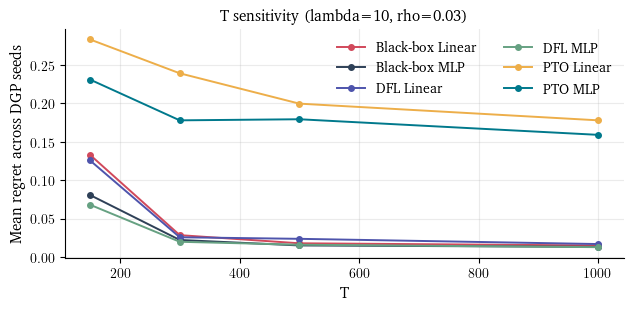

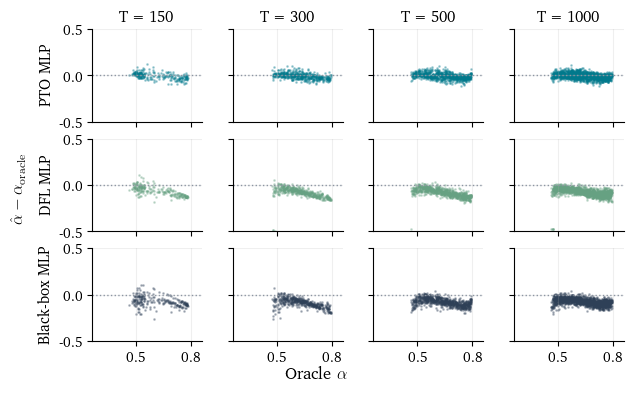

In [3]:
LAMBDA_FIXED = 10.0
RHO_FIXED = 0.03
t_data = complete_slice(metrics, 'T', {'lambda_shortfall': LAMBDA_FIXED, 'rho_scale': RHO_FIXED})
t_summary = sensitivity_summary(t_data, 'T')
print(f"Complete T values: {sorted(t_summary['T'].unique())}")
show_table(t_summary, 'T')
plot_sensitivity(t_summary, 'T', f'T sensitivity (lambda={LAMBDA_FIXED:g}, rho={RHO_FIXED:g})', 'T_sensitivity_mean_regret.pdf')
residual_panel([150, 300, 500, 1000], 'T', {'rho_scale': .03, 'lambda_shortfall': 10}, 'Allocation residuals across sample length')

## 2. Lambda sensitivity

T = 500; rho_scale = 0.03 (baseline values).

Complete lambda values: [np.float64(0.2), np.float64(1.0), np.float64(10.0), np.float64(50.0)]


model,PTO Linear,PTO MLP,Persistence,Persistence MA4,DFL Linear,DFL MLP,Black-box Linear,Black-box MLP
lambda_shortfall,,,,,,,,
0.2,0.0050 (0.0005),0.0045 (0.0007),0.0050 (0.0007),0.0052 (0.0010),0.0050 (0.0006),0.0043 (0.0007),0.0049 (0.0006),0.0042 (0.0008)
1.0,0.0220 (0.0054),0.0199 (0.0045),0.0260 (0.0042),0.0232 (0.0051),0.0111 (0.0011),0.0094 (0.0017),0.0104 (0.0018),0.0094 (0.0021)
10.0,0.1997 (0.0603),0.1794 (0.0479),0.2498 (0.0449),0.2124 (0.0518),0.0237 (0.0093),0.0160 (0.0042),0.0179 (0.0029),0.0151 (0.0033)
50.0,0.9526 (0.2949),0.8524 (0.2359),1.2110 (0.2276),1.0171 (0.2584),0.0667 (0.0403),0.0220 (0.0051),0.0358 (0.0159),0.0206 (0.0055)


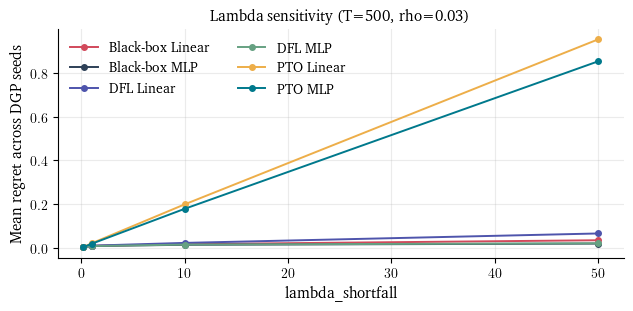

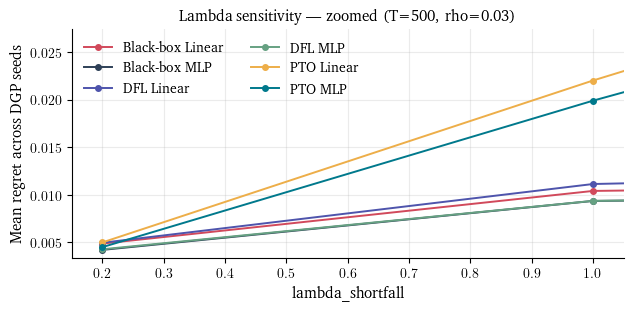

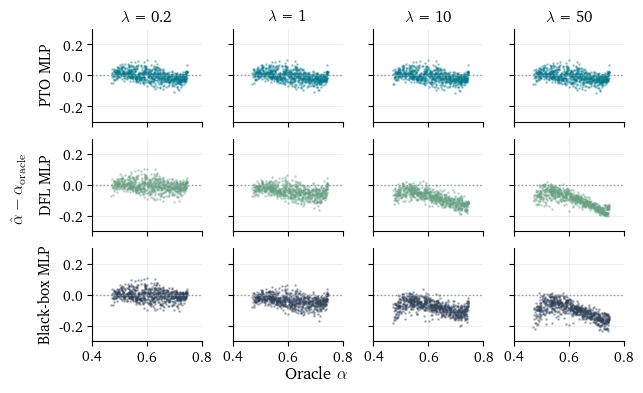

In [4]:
T_FIXED = 500
RHO_FIXED = 0.03
lambda_data = complete_slice(metrics, 'lambda_shortfall', {'T': T_FIXED, 'rho_scale': RHO_FIXED})
lambda_summary = sensitivity_summary(lambda_data, 'lambda_shortfall')
print(f'Complete lambda values: {sorted(lambda_summary.lambda_shortfall.unique())}')
show_table(lambda_summary, 'lambda_shortfall')
plot_sensitivity(lambda_summary, 'lambda_shortfall', f'Lambda sensitivity (T={T_FIXED}, rho={RHO_FIXED:g})', 'lambda_sensitivity_mean_regret.pdf')
plot_sensitivity(lambda_summary, 'lambda_shortfall', f'Lambda sensitivity — zoomed (T={T_FIXED}, rho={RHO_FIXED:g})', 'lambda_sensitivity_mean_regret_zoomed_0_1.pdf', xlim=(0.15, 1.05), tight_y=True)
residual_panel([.2, 1, 10, 50], 'lambda_shortfall', {'rho_scale': .03, 'T': 500}, 'Allocation residuals across lambda', xlim=(0.4, 0.8), ylim=(-0.3, 0.3), filename='allocation_residuals_lambda.pdf')

## 3. Rho sensitivity

Lambda = 10; T = 500 (baseline values).

Complete rho values: [np.float64(0.03), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0)]


model,PTO Linear,PTO MLP,Persistence,Persistence MA4,DFL Linear,DFL MLP,Black-box Linear,Black-box MLP
rho_scale,,,,,,,,
0.03,0.1997 (0.0603),0.1794 (0.0479),0.2498 (0.0449),0.2124 (0.0518),0.0237 (0.0093),0.0160 (0.0042),0.0179 (0.0029),0.0151 (0.0033)
0.10,0.1808 (0.0544),0.1585 (0.0456),0.4088 (0.0666),0.2435 (0.0647),0.0231 (0.0084),0.0167 (0.0038),0.0201 (0.0054),0.0159 (0.0035)
0.25,0.1430 (0.0459),0.1266 (0.0443),0.7135 (0.1098),0.3149 (0.0807),0.0218 (0.0066),0.0163 (0.0047),0.0205 (0.0051),0.0165 (0.0042)
0.50,0.1006 (0.0349),0.0856 (0.0362),1.1719 (0.1505),0.4504 (0.0973),0.0205 (0.0055),0.0172 (0.0047),0.0202 (0.0049),0.0171 (0.0039)
1.00,0.0542 (0.0235),0.0456 (0.0228),1.9726 (0.1795),0.7963 (0.1247),0.0209 (0.0045),0.0184 (0.0045),0.0203 (0.0049),0.0174 (0.0045)


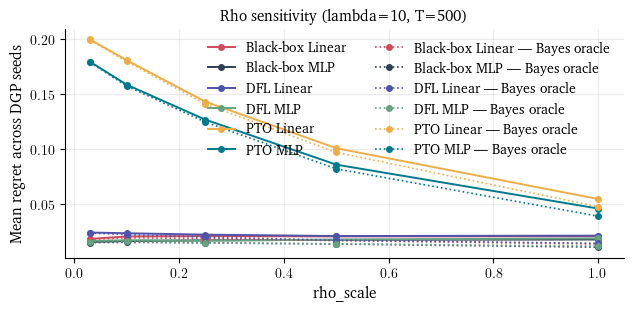

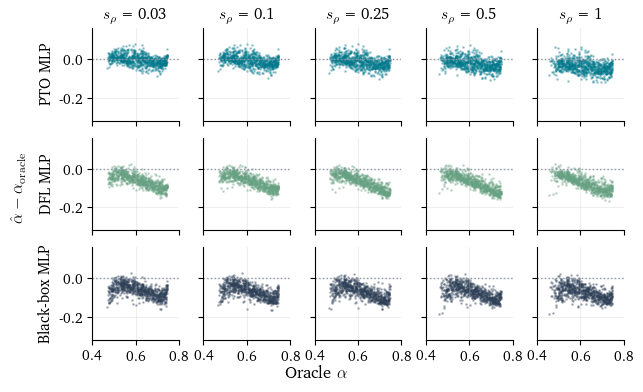

In [5]:
LAMBDA_FIXED = 10.0
T_FIXED = 500
rho_data = complete_slice(metrics, 'rho_scale', {'lambda_shortfall': LAMBDA_FIXED, 'T': T_FIXED})
rho_summary = sensitivity_summary(rho_data, 'rho_scale')
print(f'Complete rho values: {sorted(rho_summary.rho_scale.unique())}')
show_table(rho_summary, 'rho_scale')
MODEL_SPECS = [('pto', 'linear', 'PTO Linear', MINOU_COLORS['gold']),
              ('pto', 'mlp', 'PTO MLP', MINOU_COLORS['teal']),
              ('dfl', 'linear', 'DFL Linear', MINOU_COLORS['purple']),
              ('dfl', 'mlp', 'DFL MLP', MINOU_COLORS['sage']),
              ('blackbox', 'linear', 'Black-box Linear', MINOU_COLORS['coral']),
              ('blackbox', 'mlp', 'Black-box MLP', MINOU_COLORS['navy'])]
rho_rows = []
for family, architecture, label, color in MODEL_SPECS:
    for rho in [RHO_FIXED, .1, .25, .5, 1.0]:
        for seed in SEEDS:
            path = paths.timeseries_csv(family, architecture, seed, LAMBDA_FIXED, T_FIXED, rho)
            frame = pd.read_csv(path)
            foresight_col = 'regret_vs_foresight' if 'regret_vs_foresight' in frame else 'regret'
            rho_rows.append({'model': label, 'color': color, 'rho_scale': rho, 'foresight': frame[foresight_col].mean(), 'bayes': frame['regret_vs_bayes'].mean()})
rho_plot = pd.DataFrame(rho_rows).groupby(['model','color','rho_scale']).mean(numeric_only=True).reset_index()
plot_sensitivity(rho_summary, 'rho_scale', f'Rho sensitivity (lambda={LAMBDA_FIXED:g}, T={T_FIXED})', 'rho_sensitivity_mean_regret.pdf')
residual_panel([RHO_FIXED, .1, .25, .5, 1.0], 'rho_scale', {'lambda_shortfall': 10, 'T': 500}, 'Allocation residuals across rho scale', xlim=(0.4, 0.8), ylim=(-0.4, 0.2), filename='allocation_residuals_rho_scale.pdf')

## Sensitivity Panel

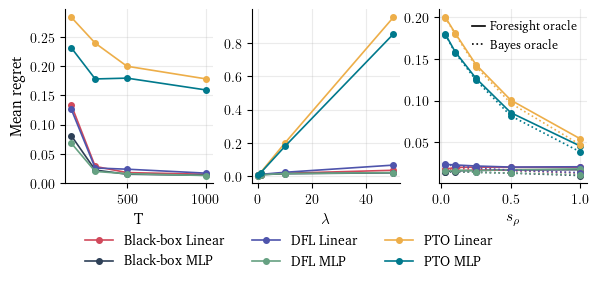

In [8]:
def plot_sensitivity_panel():
    summaries = [(t_summary, 'T', 'T'),
                 (lambda_summary, 'lambda_shortfall', r'$\lambda$'),
                 (rho_summary, 'rho_scale', r'$s_\rho$')]
    fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 3.0), sharey=False,)
    fig.subplots_adjust(left=0.14, right=0.98, bottom=0.30, top=0.88, wspace=0.26)
    handles, labels = [], []
    for ax, (summary, varying, xlabel) in zip(axes, summaries):
        for model, g in summary.groupby('model', sort=False):
            if model in PLOT_EXCLUDED_MODELS:
                continue
            g = g.sort_values(varying)
            line, = ax.plot(g[varying], g.mean_regret, marker='o', lw=1.2,
                        color=MODEL_COLORS[model], label=model)
            if model not in labels:
                handles.append(line); labels.append(model)
        if varying == 'rho_scale':
            for (model, color), rg in rho_plot.groupby(['model', 'color']):
                rg = rg.sort_values('rho_scale')
                ax.plot(rg.rho_scale, rg.bayes, marker='o', color=color, lw=1.2, ls=':')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Mean regret' if ax is axes[0] else '')
        ax.grid(alpha=.25)
        if varying == 'rho_scale':
            style_handles = [Line2D([0], [0], color='black', lw=1.2, ls='-', label='Foresight oracle'),
                             Line2D([0], [0], color='black', lw=1.2, ls=':', label='Bayes oracle')]
            ax.legend(handles=style_handles, loc='upper right', fontsize=9, frameon=False, handlelength=1.0, handletextpad=0.4)
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.025))
    fig.savefig(FIGURES_DIR / 'sensitivity_panel.pdf', dpi=200, bbox_inches='tight')
    plt.show()
plot_sensitivity_panel()

## Summary Table

In [9]:
def _appendix_fmt(x):
    x = float(x)
    if abs(x) > 0 and abs(x) < 0.0005:
        return f'{x:.4g}'
    return f'{x:.3f}'

def appendix_robustness_table(df, varying, title):
    df = df[(df['architecture'] == 'mlp') &
            (~df['model_family'].isin(['persistence', 'persistence_ma4']))].copy()
    rows = []
    for (value, family, architecture), g in df.groupby(
            [varying, 'model_family', 'architecture'], sort=True):
        rows.append({
            'Parameter value': value,
            'Model': MODEL_LABELS[(family, architecture)],
            'Mean regret': g['mean_regret'].mean(),
            'SD': g['mean_regret'].std(),
            'Median regret': g['median_regret'].median(),
            'Median regret range': f"[{_appendix_fmt(g['median_regret'].min())}, {_appendix_fmt(g['median_regret'].max())}]",
        })
    table = pd.DataFrame(rows)
    table['Model'] = table['Model'].str.replace(' MLP', '', regex=False)
    family_order = {'PTO': 0, 'DFL': 1, 'Black-box': 2}
    table['_model_order'] = table['Model'].map(family_order)
    table = table.sort_values(['Parameter value', '_model_order']).drop(columns='_model_order')
    table['Parameter value'] = table['Parameter value'].map(lambda x: f'{float(x):g}')
    table = table.set_index(['Parameter value', 'Model'])
    latex = table.to_latex(escape=False, multirow=True, column_format='llrrrr',
        formatters={'Mean regret': _appendix_fmt, 'SD': _appendix_fmt,
                    'Median regret': _appendix_fmt},
        caption=title, label=f'tab:appendix_{varying}')
    return table

appendix_tables = {
    'Sample length': appendix_robustness_table(t_data, 'T',
        'Simulation sensitivity to sample length.'),
    'Penalty parameter': appendix_robustness_table(lambda_data, 'lambda_shortfall',
        'Simulation sensitivity to the penalty parameter.'),
    'Correlation scale': appendix_robustness_table(rho_data, 'rho_scale',
        'Simulation sensitivity to the correlation scale.'),
}

combined_parts = []
for dimension, table in appendix_tables.items():
    section = table.reset_index()
    section['Parameter'] = dimension
    combined_parts.append(section)
combined = pd.concat(combined_parts, ignore_index=True)
combined = combined[['Parameter', 'Parameter value', 'Model', 'Mean regret', 'SD',
                     'Median regret', 'Median regret range']]
combined = combined.set_index(['Parameter', 'Parameter value', 'Model'])
latex = combined.to_latex(escape=False, multirow=True,
    column_format='lllrrrr',
    formatters={'Mean regret': _appendix_fmt, 'SD': _appendix_fmt,
                'Median regret': _appendix_fmt},
    caption='Sensitivity Results for MLP models',
    label='tab:sensitivity_mlp')
latex = latex.replace('\\begin{table}\n', '\\begin{table}\n\\centering\n\\scriptsize\n', 1)
print(latex)

\begin{table}
\centering
\scriptsize
\caption{Sensitivity Results for MLP models}
\label{tab:sensitivity_mlp}
\begin{tabular}{lllrrrr}
\toprule
 &  &  & Mean regret & SD & Median regret & Median regret range \\
Parameter & Parameter value & Model &  &  &  &  \\
\midrule
\multirow[t]{12}{*}{Sample length} & \multirow[t]{3}{*}{150} & PTO & 0.231 & 0.042 & 0.009 & [0.006, 0.186] \\
 &  & DFL & 0.068 & 0.033 & 0.015 & [0.006, 0.015] \\
 &  & Black-box & 0.081 & 0.050 & 0.014 & [0.007, 0.016] \\
\cline{2-7}
 & \multirow[t]{3}{*}{300} & PTO & 0.178 & 0.059 & 0.008 & [0.005, 0.018] \\
 &  & DFL & 0.020 & 0.008 & 0.012 & [0.008, 0.016] \\
 &  & Black-box & 0.022 & 0.010 & 0.015 & [0.010, 0.016] \\
\cline{2-7}
 & \multirow[t]{3}{*}{500} & PTO & 0.179 & 0.048 & 0.008 & [0.006, 0.011] \\
 &  & DFL & 0.016 & 0.004 & 0.014 & [0.007, 0.015] \\
 &  & Black-box & 0.015 & 0.003 & 0.013 & [0.008, 0.016] \\
\cline{2-7}
 & \multirow[t]{3}{*}{1000} & PTO & 0.159 & 0.021 & 0.008 & [0.006, 0.009] \\
 &  & DF